In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from lifelines import CoxPHFitter

# Load Dataset

In [2]:
df = pd.read_excel("online_retail_II.xlsx")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(525461, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


# Data Cleaning

In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [7]:
df = df.dropna(subset=['Customer ID'])

In [8]:
df = df.drop_duplicates()

In [9]:
df = df[df['Quantity'] > 0]

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [12]:
df.rename(
    columns={'Customer ID': 'CustomerID'},
    inplace=True
)

In [13]:
df.shape

(400947, 9)

# Dataset Date Range

In [14]:
print("Start Date:", df['InvoiceDate'].min())
print("End Date:", df['InvoiceDate'].max())

Start Date: 2009-12-01 07:45:00
End Date: 2010-12-09 20:01:00


# Train / Future Split

In [15]:
max_date = df['InvoiceDate'].max()
split_date = max_date - pd.DateOffset(months=3)

In [16]:
print("Split Date:", split_date)

Split Date: 2010-09-09 20:01:00


In [17]:
historical = df[
    df['InvoiceDate'] < split_date
]

In [18]:
future = df[
    df['InvoiceDate'] >= split_date
]

In [19]:
print("Historical Shape:", historical.shape)

Historical Shape: (252765, 9)


In [20]:
print("Future Shape:", future.shape)

Future Shape: (148182, 9)


# Feature Engineering

In [21]:
snapshot_date = historical['InvoiceDate'].max() + pd.Timedelta(days=1)

In [22]:
rfm = historical.groupby('CustomerID').agg({
    'InvoiceDate': lambda x:
        (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

In [23]:
rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

# Tenure

In [24]:
tenure = historical.groupby(
    'CustomerID'
)['InvoiceDate'].agg(
    ['min', 'max']
).reset_index()

In [25]:
tenure['Tenure'] = (
    tenure['max'] - tenure['min']
).dt.days

In [26]:
rfm = rfm.merge(
    tenure[['CustomerID', 'Tenure']],
    on='CustomerID'
)

# Average Purchase Interval

In [27]:
temp = historical.sort_values(
    ['CustomerID', 'InvoiceDate']
)

temp['PreviousDate'] = temp.groupby(
    'CustomerID'
)['InvoiceDate'].shift(1)

In [28]:
temp['Gap'] = (
    temp['InvoiceDate']
    -
    temp['PreviousDate']
).dt.days

In [29]:
avg_gap = temp.groupby(
    'CustomerID'
)['Gap'].mean().reset_index()

In [30]:
avg_gap.columns = [
    'CustomerID',
    'AvgPurchaseInterval'
]

In [31]:
rfm = rfm.merge(
    avg_gap,
    on='CustomerID',
    how='left'
)

In [32]:
rfm['AvgPurchaseInterval'] = (
    rfm['AvgPurchaseInterval']
    .fillna(0)
)

# Unique Products Purchased

In [33]:
products = historical.groupby(
    'CustomerID'
)['StockCode'].nunique().reset_index()

In [34]:
products.columns = [
    'CustomerID',
    'UniqueProducts'
]

In [35]:
rfm = rfm.merge(
    products,
    on='CustomerID'
)

# Future CLV Target

In [36]:
# CLV = Future Spending
future_clv = future.groupby(
    'CustomerID'
)['TotalPrice'].sum().reset_index()

In [37]:
future_clv.columns = [
    'CustomerID',
    'CLV'
]

In [38]:
# Merge Features + Target
data = rfm.merge(
    future_clv,
    on='CustomerID',
    how='inner'
)

In [39]:
print("Final Dataset Shape:", data.shape)

Final Dataset Shape: (1946, 8)


In [40]:
# Check Missing Values
data.isnull().sum()

CustomerID             0
Recency                0
Frequency              0
Monetary               0
Tenure                 0
AvgPurchaseInterval    0
UniqueProducts         0
CLV                    0
dtype: int64

# Visualisations

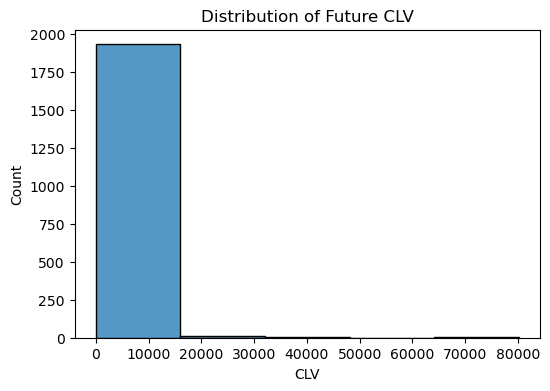

In [41]:
plt.figure(figsize=(6,4))
sns.histplot(data['CLV'], bins=5)
plt.title("Distribution of Future CLV")
plt.show()

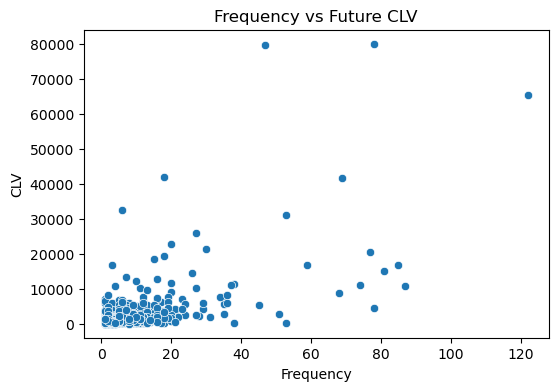

In [42]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=data,
    x='Frequency',
    y='CLV'
)
plt.title("Frequency vs Future CLV")
plt.show()

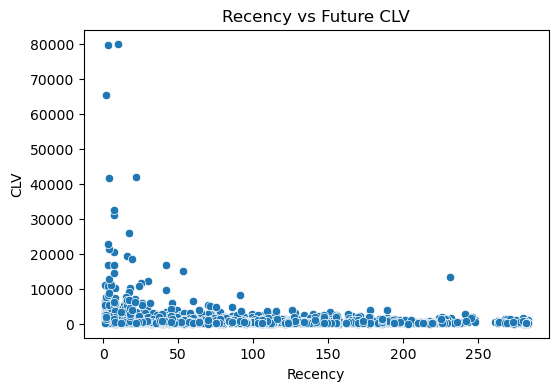

In [43]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=data,
    x='Recency',
    y='CLV'
)
plt.title("Recency vs Future CLV")
plt.show()

# Features and Target

In [44]:
X = data[
[
    'Recency',
    'Frequency',
    'Tenure',
    'AvgPurchaseInterval',
    'UniqueProducts'
]
]

y = data['CLV']

# Scaling

In [45]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [46]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

# Linear Regression

In [47]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
pred_lr = lr.predict(X_test)

In [49]:
print(
    "MAE:",
    mean_absolute_error(y_test, pred_lr)
)

MAE: 1007.8209211892103


In [50]:
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(y_test, pred_lr)
    )
)

RMSE: 2466.0928954783067


In [51]:
print(
    "R2:",
    r2_score(y_test, pred_lr)
)

R2: 0.5754414706920242


# Random Forest


In [52]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
pred_rf = rf.predict(X_test)

In [54]:
print(
    "MAE:",
    mean_absolute_error(y_test, pred_rf)
)

MAE: 1071.793256023199


In [55]:
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(y_test, pred_rf)
    )
)

RMSE: 3260.0119273692662


In [56]:
print(
    "R2:",
    r2_score(y_test, pred_rf)
)

R2: 0.2580799904330341


# Feature Importance

In [57]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [58]:
importance = importance.sort_values(
    'Importance',
    ascending=False
)

In [59]:
print(importance)

               Feature  Importance
1            Frequency    0.544023
4       UniqueProducts    0.171634
3  AvgPurchaseInterval    0.139570
2               Tenure    0.079326
0              Recency    0.065447


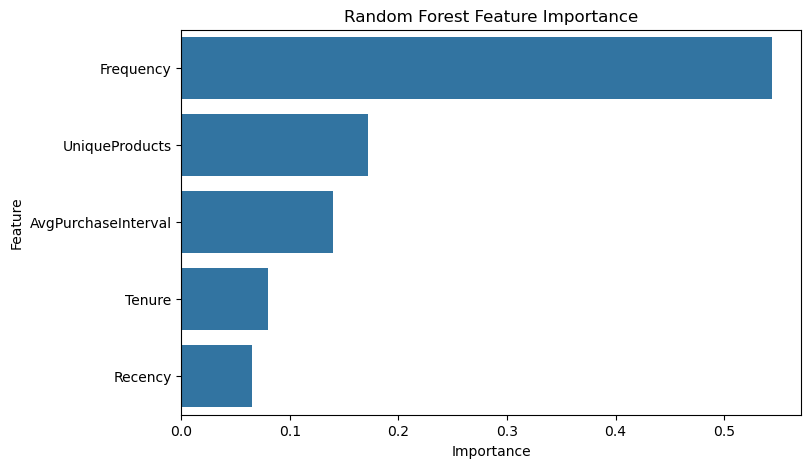

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title("Random Forest Feature Importance")
plt.show()

# Survival Analysis

In [61]:
data['Churn'] = (
    data['Recency'] > 90
).astype(int)

survival_df = data[
[
    'Tenure',
    'Churn',
    'Recency',
    'Frequency',
    'AvgPurchaseInterval',
    'UniqueProducts'
]
]

In [62]:
cph = CoxPHFitter()

In [63]:
cph.fit(
    survival_df,
    duration_col='Tenure',
    event_col='Churn'
)

<lifelines.CoxPHFitter: fitted with 1946 total observations, 1290 right-censored observations>

In [64]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1946 total observations, 1290 right-censored observations>
             duration col = 'Tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 1946
number of events observed = 656
   partial log-likelihood = -3652.61
         time fit was run = 2026-06-22 15:28:29 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Recency              0.02      1.02      0.00            0.01            0.02                1.01                1.02
Frequency           -0.71      0.49      0.05           -0.81           -0.60                0.44                0.55
AvgPurchaseInterval -0.21      0.81      0.03           -0.27           -0.16                0.77                0.85
UniqueProducts      -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99

                     cmp to      z      p  -log2(p)
covariate                                          
Recency                0.00  25.31 <0.005    467.23
Frequency              0.00 -13.29 <0.005    131.43
AvgPurchaseInterval    0.00  -7.71 <0.005     46.17
UniqueProducts         0.00  -6.09 <0.005     29.71
---
Concordance = 0.96
Partial AIC = 7313.22
log-likelihood ratio test = 2176.58 on 4 df
-log2(p) of ll-ratio test = inf